**Лабораторная работа №2. Информативные признаки речевых сигналов: извлечение признаков**

**Цель работы:** изучение процедуры построения информативных акустических признаков для речевых сигналов.

**Краткое описание**: в рамках настоящей лабораторной работы требуется познакомиться с процедурами предобработки речевых сигналов и извлечения информативных признаков. В работе предлагается научиться извлекать кратковременные энергии мел-частотных полос (MFBs, mel filter banks) и мел-частотные кепстральные коэффициенты (MFCCs, mel frequency cepstral coeffitients).

**Варианты**: id10276, id10288.

**Данные**: используется тестовая часть базы [VoxCeleb1](http://www.robots.ox.ac.uk/~vgg/data/voxceleb/vox1.html).

**Содержание лабораторной работы:**

1. Подготовка данных для анализа.
2. Выполнение процедуры высокочастотной фильтрации (преэмфазис) речевого сигнала.
3. Вычисление акустических признаков разных видов.
4. Выполнение локальных центрирования и масштабирования акустических признаков.
5. Построение распределений первых трёх компонент полученных акустических признаков для мужских и женских голосов.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

_LAB_DIR = os.getcwd()
if not os.path.isfile(os.path.join(_LAB_DIR, "exercises_blank.py")):
    raise RuntimeError
_DATA_DIR = os.path.abspath(os.path.join(_LAB_DIR, "..", "data"))
_META_PATH = os.path.join(_LAB_DIR, "metadata", "meta.txt")
_DATASETS_LIST = os.path.join(_LAB_DIR, "data", "lists", "datasets.txt")

sys.path.insert(0, _LAB_DIR)

from common import download_dataset, extract_dataset

from math import sqrt, pi
from scipy.fftpack import dct

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import hist, plot, show, grid, title, xlabel, ylabel, legend, axis, imshow

from mpl_toolkits.axes_grid1 import make_axes_locatable

from skimage.morphology import opening, closing
from torchaudio.transforms import Resample
from multiprocessing import Pool
import torchaudio

from exercises_blank import split_meta_line, preemphasis, framing, power_spectrum
from exercises_blank import compute_fbank_filters, compute_fbanks_features, compute_mfcc, mvn_floating



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/alice/Documents/ITMO/2_sem/OZiR/lab2/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/alice/Documents/ITMO/2_sem/OZiR/lab2/.venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/alice/Documents/ITMO/2_sem/OZiR/lab2/.venv/lib/python3.12/site-packages/ipykern

**1. Подготовка данных для анализа**

В ходе выполнения лабораторной работы необходимы данные для осуществления процедуры вычисления акустических признаков. Возьмём в качестве этих данных несколько звукозаписей голосов людей мужского и женского пола, сохраненных в формат *wav*, выбранных из корпуса [VoxCeleb1 test set](https://thor.robots.ox.ac.uk/~vgg/data/voxceleb/vox1a/vox1_test_wav.zip). Данный корпус содержит 4,874 звукозаписи (частота дискретизации равна 16кГц) 40 дикторов мужского и женского пола, разговаривающих на английском языке.

В рамках настоящего пункта требуется выполнить загрузку и распаковку звуковых wav-файлов из корпуса VoxCeleb1 test set.

![Рисунок 1](https://analyticsindiamag.com/wp-content/uploads/2020/12/image.png "VoxCeleb. Крупномасштабная аудиовизуальная база данных человеческой речи.")

In [2]:
with open(_DATASETS_LIST, "r") as f:
    lines = f.readlines()

download_dataset(lines, user="voxceleb1902", password="nx0bl2v2", save_path=_DATA_DIR)

/Users/alice/Documents/ITMO/2_sem/OZiR/data/vox1_test_wav.zip: No such file or directory
/Users/alice/Documents/ITMO/2_sem/OZiR/data/vox1_test_wav.zip: No such file or directory
/Users/alice/Documents/ITMO/2_sem/OZiR/data/vox1_test_wav.zip: No such file or directory
--2026-04-11 11:36:47--  https://thor.robots.ox.ac.uk/~vgg/data/voxceleb/vox1a/vox1_test_wav.zip
Распознаётся thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)… 129.67.95.98
Подключение к thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... соединение установлено.
HTTP-запрос отправлен. Ожидание ответа… 308 Permanent Redirect
Адрес: https://thor.robots.ox.ac.uk/voxceleb/vox1a/vox1_test_wav.zip [переход]
--2026-04-11 11:36:48--  https://thor.robots.ox.ac.uk/voxceleb/vox1a/vox1_test_wav.zip
Повторное использование соединения с thor.robots.ox.ac.uk:443.
HTTP-запрос отправлен. Ожидание ответа… 401 Unauthorized
Выбранная аутентификация: Basic realm="VoxCeleb1 Dataset"
Повторное использование соединения с thor.robots.ox.ac.

Checksum successful vox1_test_wav.zip.


In [3]:
extract_dataset(
    save_path=os.path.join(_DATA_DIR, "voxceleb1_test"),
    fname=os.path.join(_DATA_DIR, "vox1_test_wav.zip"),
)

Extracting of /Users/alice/Documents/ITMO/2_sem/OZiR/data/vox1_test_wav.zip is successful.


**2. Выполнение процедуры высокочастотной фильтрации (преэмфазис) речевого сигнала**

В рамках настоящего пункта предлагается изучить процедуру предобработки речевых сигналов, получившую название преэмфазис. *Преэмфазис (pre-emphasis)* – применение фильтра верхних частот к сигналу до процедуры извлечения признаков для того, чтобы компенсировать тот факт, что обычно вокализованная речь содержит на низких частотах намного больше энергии, чем невокализованная речь на высоких. Обозначим через $x(n)$ обрабатываемый сигнал, а через $y(n)$ результат обработки, тогда процедура преэмфазиса может быть описана с помощью следующего выражения:

$$y(n) = x(n) + \alpha x(n-1).$$

Выражение выше представляет собой *линейное разностное уравнение с постоянными коэффициентами* и позволяет описать процедуру работы *нерекурсивного фильтра первого порядка с конечной импульсной характеристикой*. Параметр $\alpha$ является единственным параметром рассматриваемого фильтра. В случае, когда параметр $\alpha$ является отрицательным, рассматриваемый фильтр обладает свойствами *фильтра верхних частот*. Для выполнения процедуры преэмфазиса обычно параметр $\alpha = -0.97$.

В рамках настоящего пункта требуется:

1. Загрузить анализируемый речевой сигнал.

2. Выполнить процедуру преэмфазиса по отношению к загруженному речевому сигналу.

3. Сравнить спектры речевых сигналов до и после процедуры преэмфазиса.

Ниже — общий мел-банк и по очереди полный пайплайн признаков для каждого варианта.

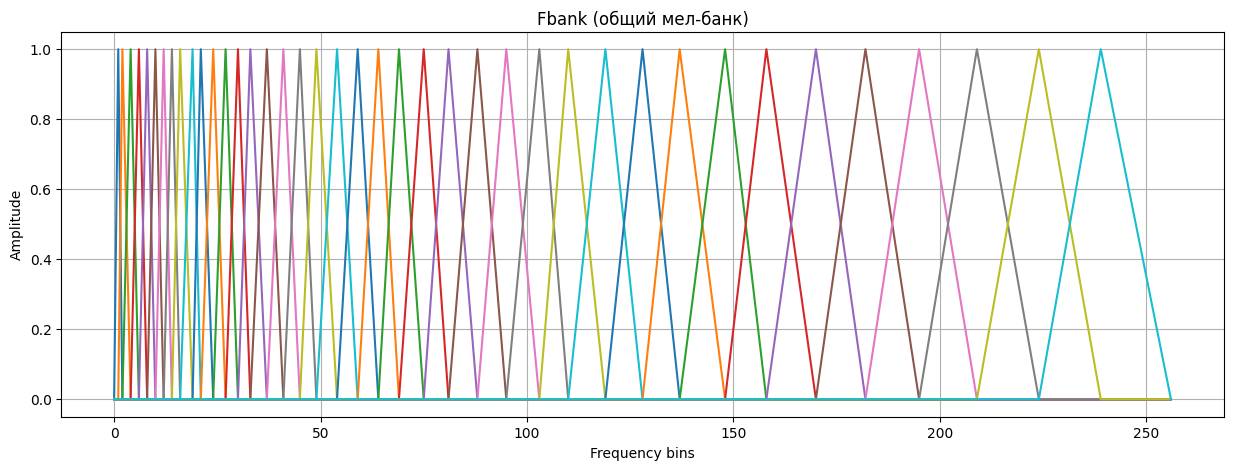

Загрузка: id10276 ../data/voxceleb1_test/wav/id10276/5WOZXLMujwY/00003.wav


RuntimeError: Numpy is not available

In [5]:
SPEAKER_IDS = ("id10276", "id10288")

with open(_META_PATH, "r") as f:
    list_lines = f.readlines()
p = Pool(1)
speaker_ids, genders, paths = zip(*p.map(split_meta_line, list_lines[1:]))
p.close()
path_by_id = dict(zip(speaker_ids, paths))

fbank = compute_fbank_filters(nfilt=40, sample_rate=16000, NFFT=512)

plt.figure(figsize=(15, 5))
plot_a = plt.subplot()
plt.subplots_adjust(wspace=0, hspace=1)
nfilt = fbank.shape[0]
for k in range(nfilt):
    plot_a.plot(fbank[k, :])
plot_a.set_xlabel("Frequency bins")
plot_a.set_ylabel("Amplitude")
plot_a.title.set_text("Fbank (общий мел-банк)")
plot_a.grid()
plt.show()

for SPEAKER_ID in SPEAKER_IDS:
    path_to_wav = path_by_id[SPEAKER_ID]
    print("Загрузка:", SPEAKER_ID, path_to_wav)

    signal, sample_rate = torchaudio.load(path_to_wav)
    signal = signal.numpy().squeeze(axis=0)
    signal = signal / np.abs(signal).max()

    signal = signal[0 : int(3.5 * sample_rate)]

    plt.figure(figsize=(15, 5))
    plt.suptitle(f"Диктор {SPEAKER_ID}: осциллограмма и спектрограмма (3.5 с)", y=1.02)
    plot_a = plt.subplot(211)
    plt.subplots_adjust(wspace=0, hspace=0.5)
    plot_a.plot(signal)
    plot_a.set_xlabel("n")
    plot_a.set_ylabel("x(n)")
    plot_a.grid()
    plot_b = plt.subplot(212)
    plot_b.specgram(signal, NFFT=1024, Fs=sample_rate, noverlap=900)
    plot_b.set_xlabel("Time, s")
    plot_b.set_ylabel("Frequency, Hz")
    plt.show()

    emphasized_signal = preemphasis(signal)

    plt.figure(figsize=(15, 5))
    plt.suptitle(f"Диктор {SPEAKER_ID}: спектрограммы до/после преэмфазиса", y=1.02)
    plot_a = plt.subplot(211)
    plt.subplots_adjust(wspace=0, hspace=1)
    plot_a.specgram(signal, NFFT=1024, Fs=sample_rate, noverlap=900)
    plot_a.set_xlabel("Time, s")
    plot_a.set_ylabel("Frequency, Hz")
    plot_a.title.set_text("Original signal")
    plot_b = plt.subplot(212)
    plot_b.specgram(emphasized_signal, NFFT=1024, Fs=sample_rate, noverlap=900)
    plot_b.set_xlabel("Time, s")
    plot_b.set_ylabel("Frequency, Hz")
    plot_b.title.set_text("Emphasized signal")
    plt.show()

    frames = framing(emphasized_signal)
    print(f"{SPEAKER_ID}: shape фреймов", frames.shape)

    pow_frames = power_spectrum(frames)

    filter_banks_features = compute_fbanks_features(pow_frames, fbank)

    plt.figure(figsize=(15, 5))
    plt.suptitle(f"Диктор {SPEAKER_ID}: сигнал и лог-энергии мел-банка", y=1.02)
    plt.subplots_adjust(wspace=0, hspace=1)
    plot_a = plt.subplot(211)
    plot_a.plot(signal)
    plot_a.set_xlabel("n")
    plot_a.set_ylabel("x(n)")
    plot_a.grid()
    plot_b = plt.subplot(212)
    plot_b.imshow(filter_banks_features.T, origin="lower")
    plot_b.set_xlabel("Time bins")
    plot_b.set_ylabel("Frequency band bins")
    plot_b.title.set_text("Fbank energies")
    plt.show()

    mfcc = compute_mfcc(filter_banks_features, num_ceps=20)

    fig = plt.figure(figsize=(15, 5))
    plt.suptitle(f"Диктор {SPEAKER_ID}: сигнал и MFCC", y=1.02)
    plt.subplots_adjust(wspace=0, hspace=1)
    plot_a = plt.subplot(211)
    plot_a.plot(signal)
    plot_a.set_xlabel("n")
    plot_a.set_ylabel("x(n)")
    plot_a.grid()
    plot_b = plt.subplot(212)
    im = plot_b.imshow(mfcc.T, origin="lower")
    divider = make_axes_locatable(plot_b)
    cax = divider.append_axes("right", size="1%", pad=0.05)
    plt.colorbar(im, cax=cax)
    plot_b.set_xlabel("Time bins")
    plot_b.set_ylabel("Coeffitients bins")
    plot_b.title.set_text("MFCCs")
    plt.show()

    mfcc_cmvn = mvn_floating(mfcc, 150, 150)
    filter_banks_features_mvn = mvn_floating(filter_banks_features, 150, 150)

    fig = plt.figure(figsize=(15, 5))
    plt.suptitle(f"Диктор {SPEAKER_ID}: нормализованные FBank и MFCC (CMVN)", y=1.02)
    plt.subplots_adjust(wspace=0, hspace=1)
    plot_b = plt.subplot(211)
    im_b = plot_b.imshow(filter_banks_features_mvn.T, origin="lower")
    divider = make_axes_locatable(plot_b)
    cax = divider.append_axes("right", size="1%", pad=0.05)
    plt.colorbar(im_b, cax=cax)
    plot_b.set_xlabel("Time bins")
    plot_b.set_ylabel("Coeffitients bins")
    plot_b.title.set_text("Normaized FBanks")
    plot_c = plt.subplot(212)
    im_c = plot_c.imshow(mfcc_cmvn.T, origin="lower")
    divider = make_axes_locatable(plot_c)
    cax = divider.append_axes("right", size="1%", pad=0.05)
    plt.colorbar(im_c, cax=cax)
    plot_c.set_xlabel("Time bins")
    plot_c.set_ylabel("Coeffitients bins")
    plot_c.title.set_text("Normaized MFCCs")
    plt.show()
    

**3. Построение распределений первых трёх компонент полученных акустических признаков для мужских и женских голосов**

Для того, чтобы грубо проверить правильность расчёта акустических признаков выше, построим гистограммы распределения первых трёх компонент логарифмов энергий на выходе банка фильтров и мел-частотных кепстральных коэффициентов по некоторой базе данных. Рассмотрим в качестве этой базы звукозаписи мужских и женских голосов дикторов, список которых представлен в **./metadata/meta.txt**. В указанном файле перечислен список из 20 звукозаписей (10 для дикторов женского пола и 10 для дикторов мужского пола) из базы VoxCeleb1 test set с указанием пути до них, идентификационного номера диктора и пола диктора (символ **f** означает женский пол, а символ **m** означает мужской пол).

Используя звукозаписи, список которых перечислен в **./metadata/meta.txt**, выполнить построение гистограмм распределения первых 3 компонент логарифмов энергий на выходе банка фильтров и мел-частотных кепстральных коэффициентов отдельно для базы мужских и женских голосов.

In [ ]:
def compute_feats(signal):
    # Function to compute mel frequency cepstral coefficient
    
    emphasized_signal = preemphasis(signal)
    frames = framing(emphasized_signal)
    pow_frames = power_spectrum(frames)
    filter_banks_features = compute_fbanks_features(pow_frames, fbank)
    mfcc = compute_mfcc(filter_banks_features, num_ceps=20)
    
    # mfcc = mvn_floating(mfcc, 150, 150)
    # filter_banks_features = mvn_floating(filter_banks_features, 150, 150)
    
    return filter_banks_features, mfcc

male_fb_features = []
female_fb_features = []
male_mfcc_features = []
female_mfcc_features = []

for (path_to_wav, gender) in zip(paths, genders):
    # Load signal
    signal, sample_rate = torchaudio.load(path_to_wav)
    signal = signal.numpy().squeeze(axis=0)
    signal = signal/np.abs(signal).max()
    
    # Processing
    filter_banks_mvn, mfcc_cmvn = compute_feats(signal)
    if gender == 'm':
        male_fb_features.append(filter_banks_mvn)
        male_mfcc_features.append(mfcc_cmvn)
    else:
        female_fb_features.append(filter_banks_mvn) 
        female_mfcc_features.append(mfcc_cmvn)
    
male_fb_features = np.concatenate(male_fb_features)
print(male_fb_features.shape)

female_fb_features = np.concatenate(female_fb_features)
print(female_fb_features.shape)

male_mfcc_features = np.concatenate(male_mfcc_features)
print(male_mfcc_features.shape)

female_mfcc_features = np.concatenate(female_mfcc_features)
print(female_mfcc_features.shape)


comp_number = 1
coeff1_male = male_fb_features[:, comp_number]
coeff1_female = female_fb_features[:, comp_number]

min_coeff1 = min(coeff1_male.min(), coeff1_female.min())
max_coeff1 = min(coeff1_male.max(), coeff1_female.max())

hist(coeff1_male,   int(sqrt(len(coeff1_male))),   histtype='step', color='green', range=(min_coeff1, max_coeff1), density=1)
hist(coeff1_female, int(sqrt(len(coeff1_female))), histtype='step', color='red',   range=(min_coeff1, max_coeff1), density=1)
xlabel('MFBs, 2nd component'); ylabel('Histogramm value'); title('Normalized histograms'); grid(); show()


**4. Контрольные вопросы**

1. Какие способы представления сигналов существуют?

2. Что такое спектр Фурье (амплитудный и фазовый)?

3. Что такое оконное преобразование Фурье?

4. Что такое спектрограмма?

5. Как выполнить процедуру преэмфазиса?

6. Описать процедуру вычисления акустических признаков.

7. Для каких целей выполняются процедуры нормализации и масштабирования акустических признаков?